# Options Strategy Practice 01: Long Call

This notebook covers the first strategy in the Linear project: **Long Call**.

We first study **static expiration payoff**, without historical data or dynamic trading. The goals are to understand:

1. When the buyer makes or loses money;
2. How to calculate maximum profit, maximum loss, and breakeven;
3. How to plot payoff / P&L curves in Python;
4. How to write the strategy in a reusable structure.

## 1. Understand the Trade

A Long Call gives you the right, but not the obligation, to buy the underlying asset at strike price `K` at expiration.

Assumptions:

- Current underlying price: 100
- Strike price `K`: 105
- Premium per share `premium`: 3
- Number of contracts: 1
- Shares per contract: 100

The buyer initially pays `3 × 100 = 300`. If the underlying price is no higher than 105 at expiration, the option expires unexercised, but the 300 remains a loss.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

spot = 100          # Current underlying price
strike = 105       # Strike price K
premium = 3        # Premium per share
contracts = 1      # Number of contracts
multiplier = 100   # Shares per option contract

initial_cost = premium * contracts * multiplier
breakeven = strike + premium

print(f'Initial premium cost: ${initial_cost:,.0f}')
print(f'Breakeven: ${breakeven:.2f}')

Initial premium cost: $300
Breakeven: $108.00


## 2. Expiration Payoff and P&L Formula

Let the underlying price at expiration be `S_T`:

- Call payoff: `max(S_T - K, 0)`
- Long Call P&L: `max(S_T - K, 0) - premium`

Payoff is the option's value at expiration; P&L also subtracts the initial premium.

In [4]:
def long_call_pnl(spot_at_expiry, strike, premium, multiplier=1, contracts=1):
    '''Return total Long Call P&L at expiration. Prices are per share.'''
    intrinsic_value = np.maximum(np.asarray(spot_at_expiry) - strike, 0)
    pnl_per_share = intrinsic_value - premium
    return pnl_per_share * multiplier * contracts

# Possible expiration prices from 60 to 160
expiry_prices = np.linspace(60, 160, 501)
payoff_per_share = np.maximum(expiry_prices - strike, 0)
pnl = long_call_pnl(expiry_prices, strike, premium, multiplier, contracts)

results = pd.DataFrame({
    'expiry_price': expiry_prices,
    'payoff_per_share': payoff_per_share,
    'total_pnl': pnl,
})
results.head()

,expiry_price,payoff_per_share,total_pnl
0,60.0,0.0,-300.0
1,60.2,0.0,-300.0
2,60.4,0.0,-300.0
3,60.6,0.0,-300.0
4,60.8,0.0,-300.0


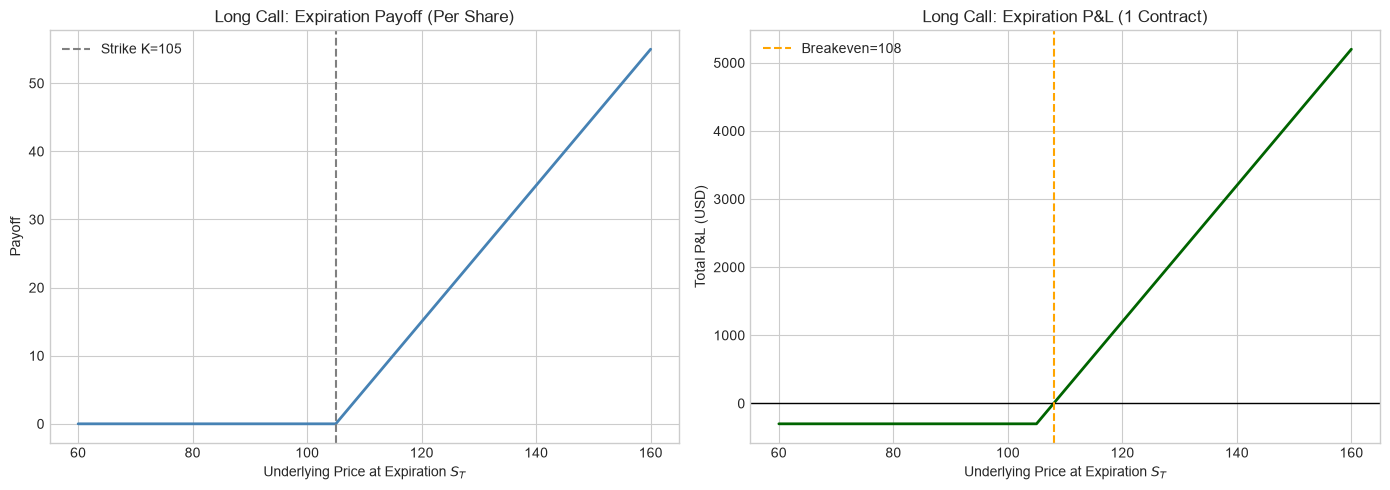

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(expiry_prices, payoff_per_share, color='steelblue', linewidth=2)
axes[0].axvline(strike, color='gray', linestyle='--', label=f'Strike K={strike}')
axes[0].set_title('Long Call: Expiration Payoff (Per Share)')
axes[0].set_xlabel('Underlying Price at Expiration $S_T$')
axes[0].set_ylabel('Payoff')
axes[0].legend()

axes[1].plot(expiry_prices, pnl, color='darkgreen', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(breakeven, color='orange', linestyle='--', label=f'Breakeven={breakeven}')
axes[1].set_title('Long Call: Expiration P&L (1 Contract)')
axes[1].set_xlabel('Underlying Price at Expiration $S_T$')
axes[1].set_ylabel('Total P&L (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Maximum Profit, Maximum Loss, and Breakeven

- **Maximum loss**: `premium × multiplier × contracts`, which is **$300** in this example.
- **Maximum profit**: Theoretically unlimited because the underlying price has no upper limit.
- **Breakeven**: `strike + premium`, which is **$108** in this example. Profit begins above 108 at expiration.

Note: This maximum loss applies to the static expiration model. Actual trading P&L can also change with implied volatility, time value, and the closing price.

In [6]:
max_loss = premium * multiplier * contracts
sample_prices = [90, 105, 108, 120]
sample = pd.DataFrame({
    'Underlying Price at Expiration': sample_prices,
    'Total P&L': long_call_pnl(sample_prices, strike, premium, multiplier, contracts)
})

print(f'Maximum Loss: ${max_loss:,.0f}')
print('Maximum Profit: Theoretically Unlimited')
print(f'Breakeven: ${breakeven:.2f}')
sample

Maximum Loss: $300
Maximum Profit: Theoretically Unlimited
Breakeven: $108.00


,Underlying Price at Expiration,Total P&L
0,90,-300
1,105,-300
2,108,0
3,120,1200


## 4. Compare with Linear Guidance

This version covers the first layer of the project requirements:

- payoff: option value at expiration
- maximum return: theoretically unlimited for a Long Call
- maximum loss: premium paid
- breakeven: strike price + premium
- expiration curve: complete expiration P&L curve

The remaining work includes backtesting, entry, exit, position sizing, transaction costs, and real historical data. Confirm that you can explain the two charts before moving on.

## 5. Exercises

Modify the parameters and rerun all code:

1. Change `strike` to 100. What is the new breakeven?
2. Change `premium` to 5. How do maximum loss and breakeven change?
3. Change `contracts` to 10. Does the curve shape change? How does total P&L change?
4. Explain why P&L is not 0 when the expiration price is below the strike, but instead equals the negative premium cost.